# Implementación de modelos de machine learning sobre dataset PLAStiCC

## Libs

In [33]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import time
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score


## Visualización de los datos de plasticc

In [17]:
train_metadata = pd.read_csv('/content/plasticc_train_metadata.csv')
train_targets  = pd.read_csv('/content/plasticc_train_target_names.csv')
train_lc      = pd.read_csv('/content/plasticc_train_lightcurves.csv')
print("Paso 2: CSVs cargados")
print("=== METADATA ===")
print(train_metadata.head())
print(train_metadata.info())

print("\n=== LIGHTCURVES ===")
print(train_lc.head())
print(train_lc.info())

print("\n=== TARGETS ===")
print(train_targets.head())


Paso 2: CSVs cargados
=== METADATA ===
   object_id        ra     decl  ddf_bool  hostgal_specz  hostgal_photoz  \
0        615  349.0461 -61.9438         1          0.000           0.000   
1        713   53.0859 -27.7844         1          1.818           1.627   
2        730   33.5742  -6.5796         1          0.232           0.226   
3        745    0.1899 -45.5867         1          0.304           0.281   
4       1124  352.7113 -63.8237         1          0.193           0.241   

   hostgal_photoz_err  distmod  mwebv  target  ...  true_rv  true_av  \
0               0.000   -9.000  0.017      92  ...      0.0      0.0   
1               0.255   45.406  0.007      88  ...      0.0      0.0   
2               0.016   40.256  0.021      42  ...      0.0      0.0   
3               1.152   40.795  0.007      90  ...      0.0      0.0   
4               0.018   40.417  0.024      90  ...      0.0      0.0   

   true_peakmjd  libid_cadence  tflux_u  tflux_g  tflux_r  tflux_i  tfl

Objeto 130772921 tiene 144 observaciones
Clase: 65 -  Mdwarf
         object_id         mjd  passband        flux   flux_err  detected_bool
1421443  130772921  59583.1166         0    8.315109   8.608242              0
1421444  130772921  59588.0852         5  -10.155349  30.024992              0
1421445  130772921  59589.0482         5   -2.512353  18.140255              0
1421446  130772921  59591.0874         4    9.348175   9.424926              0
1421447  130772921  59596.0496         5    2.830231  23.455517              0
1421448  130772921  59598.1295         4    8.653300  16.316519              0
1421449  130772921  59625.1382         5  211.992584  27.878538              1
1421450  130772921  59627.0297         4   -2.251453   9.897296              0
1421451  130772921  59630.0251         5   32.095779  20.697596              0
1421452  130772921  59634.1153         2   -4.393254   2.346865              0


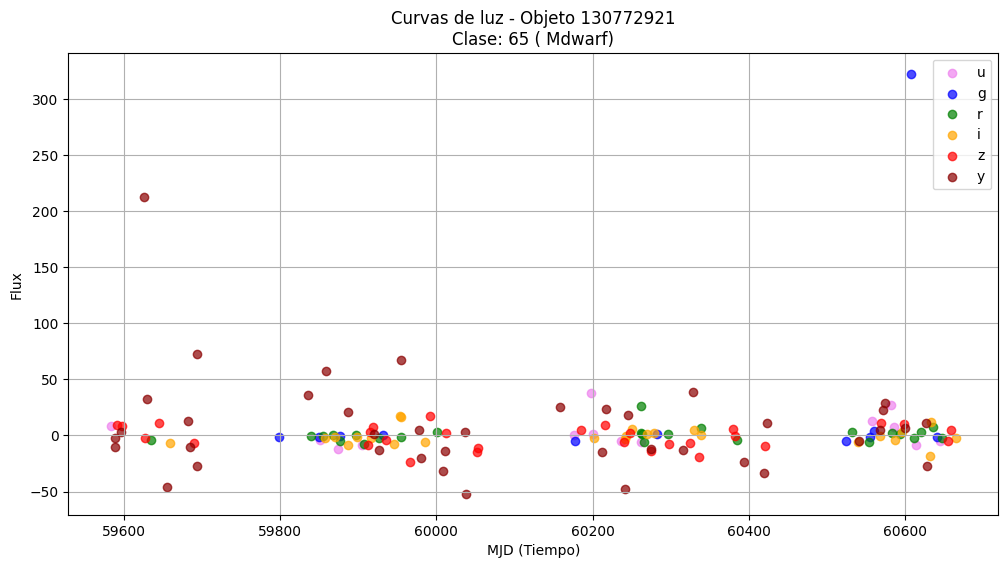

In [18]:
# Elegir un objeto específico
obj_id = 130772921  # Puedes cambiar este ID

# Filtrar las observaciones de ese objeto
obj_data = train_lc[train_lc['object_id'] == obj_id]

# Obtener la clase del objeto desde el metadata
obj_class = train_metadata[train_metadata['object_id'] == obj_id]['target'].values[0]

# Obtener el nombre de la clase (verificando el nombre exacto de la columna)
obj_class_name = train_targets[train_targets['target'] == obj_class].iloc[0, 1]  # Usar índice por seguridad

print(f"Objeto {obj_id} tiene {len(obj_data)} observaciones")
print(f"Clase: {obj_class} - {obj_class_name}")
print(obj_data.head(10))

# Graficar las curvas de luz por banda
plt.figure(figsize=(12, 6))

# Colores para cada banda (0-5)
colors = ['violet', 'blue', 'green', 'orange', 'red', 'darkred']
band_names = ['u', 'g', 'r', 'i', 'z', 'y']

for band in range(6):
    band_data = obj_data[obj_data['passband'] == band]
    if len(band_data) > 0:
        plt.scatter(band_data['mjd'], band_data['flux'],
                   c=colors[band], label=band_names[band], alpha=0.7)

plt.xlabel('MJD (Tiempo)')
plt.ylabel('Flux')
plt.title(f'Curvas de luz - Objeto {obj_id}\nClase: {obj_class} ({obj_class_name})')
plt.legend()
plt.grid(True)
plt.show()

=== TODAS LAS CLASES EN EL DATASET ===
Número total de clases: 18

Distribución de clases:
    target  count             class_name
0        6    151   uLens-Single_GenLens
1       15    495                    TDE
2       16    924                     EB
3       42   1193                  SNIIn
4       52    183                  SNIax
5       53     30                   MIRA
6       62    484                  SNIbc
7       64    102                     KN
8       65    981                 Mdwarf
9       67    208              SNIa-91bg
10      88    370                    AGN
11      90   2313                   SNIa
12      92    239                    RRL
13      95    175                   SLSN

Total de objetos: 7848


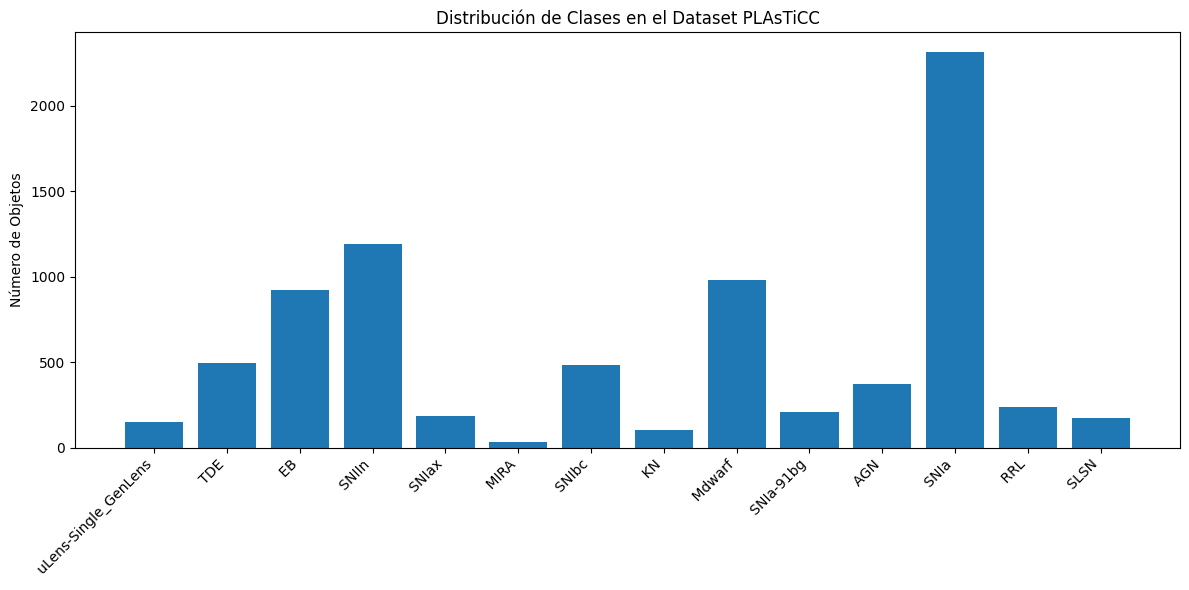

In [19]:
# Mostrar todas las clases disponibles en el dataset
print("=== TODAS LAS CLASES EN EL DATASET ===")
print(f"Número total de clases: {len(train_targets)}")
print("\nDistribución de clases:")

# Contar cuántos objetos hay por clase
class_distribution = train_metadata['target'].value_counts().sort_index()
class_info = pd.merge(class_distribution.reset_index(),
                     train_targets,
                     left_on='target',
                     right_on='target')

class_info.columns = ['target', 'count', 'class_name']
print(class_info)

print(f"\nTotal de objetos: {class_info['count'].sum()}")

# Graficar la distribución de clases
plt.figure(figsize=(12, 6))
plt.bar(class_info['class_name'], class_info['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Clases en el Dataset PLAsTiCC')
plt.ylabel('Número de Objetos')
plt.tight_layout()
plt.show()

In [20]:
# Verificar la discrepancia
print(f"Clases en train_targets: {len(train_targets)}")
print(f"Clases con datos en metadata: {len(class_distribution)}")

# Ver qué clases faltan en los datos
all_classes = set(train_targets['target'])
classes_with_data = set(class_distribution.index)
missing_classes = all_classes - classes_with_data

print(f"\nClases que no aparecen en los datos: {missing_classes}")
print(f"Número de clases sin datos: {len(missing_classes)}")

# Mostrar las clases completas de train_targets
print("\n=== TODAS LAS CLASES EN train_targets ===")
print(train_targets)

Clases en train_targets: 18
Clases con datos en metadata: 14

Clases que no aparecen en los datos: {992, 993, 994, 991}
Número de clases sin datos: 4

=== TODAS LAS CLASES EN train_targets ===
    target                   type
0        6   uLens-Single_GenLens
1       15                    TDE
2       16                     EB
3       42                  SNIIn
4       52                  SNIax
5       53                   MIRA
6       62                  SNIbc
7       64                     KN
8       65                 Mdwarf
9       67              SNIa-91bg
10      88                    AGN
11      90                   SNIa
12      92                    RRL
13      95                   SLSN
14     991   uLens-Binary_genLens
15     992                   ILOT
16     993                   CaRT
17     994                   PISN


# Funcion de visualizacion show_curves

In [21]:
def show_curves(curves):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    fig.set_facecolor('white')

    epochs = np.arange(len(curves["val_loss"])) + 1

    ax[0].plot(epochs, curves['val_loss'], label='validation')
    ax[0].plot(epochs, curves['train_loss'], label='training')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Loss evolution during training')
    ax[0].legend()

    ax[1].plot(epochs, curves['val_acc'], label='validation')
    ax[1].plot(epochs, curves['train_acc'], label='training')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Accuracy evolution during training')
    ax[1].legend()

    plt.show()

# Pre-Procesamiento de los datos

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 1️⃣ LIMPIEZA CONSERVADORA
# ==============================
print("Paso 1: Limpieza conservadora...")

# Solo eliminar outliers extremos
train_lc_clean = train_lc[
    (np.abs(train_lc['flux']) < 1e5) &      # Flux extremadamente alto
    (train_lc['flux_err'] > 0) &           # Error debe ser positivo
    (train_lc['flux_err'] < 1e4)           # Error extremadamente alto
]

# Mantener objetos con al menos 10 observaciones
min_obs = 10
obj_counts = train_lc_clean['object_id'].value_counts()
valid_ids = obj_counts[obj_counts >= min_obs].index
train_lc_clean = train_lc_clean[train_lc_clean['object_id'].isin(valid_ids)]

print(f"Observaciones después de limpieza: {len(train_lc_clean)}")
print(f"Objetos válidos: {len(valid_ids)}")

# ==============================
# 2️⃣ ESTRUCTURA POR OBJETO
# ==============================
print("Paso 2: Estructurando datos por objeto...")

objects = {}
for obj_id, group in train_lc_clean.groupby('object_id'):
    group = group.sort_values('mjd')

    # Datos originales
    mjd = group['mjd'].values
    flux = group['flux'].values
    flux_err = group['flux_err'].values
    passband = group['passband'].values

    # Target del metadata
    target_row = train_metadata[train_metadata['object_id'] == obj_id]
    if len(target_row) == 0:
        continue

    target = target_row['target'].values[0]

    objects[obj_id] = {
        'mjd': mjd,
        'flux': flux,                    # FLUX ORIGINAL
        'flux_err': flux_err,
        'passband': passband,
        'target': target
    }

print(f"Objetos procesados: {len(objects)}")

# ==============================
# 3️⃣ FUNCIONES DE FEATURES ESPECÍFICAS
# ==============================
def percent_beyond_1std(flux):
    """Porcentaje más allá de 1 std"""
    if len(flux) < 2:
        return 0
    return np.sum(np.abs(flux - np.mean(flux)) > np.std(flux)) / len(flux) * 100

def percent_close_to_median(flux):
    """Porcentaje cercano a la mediana"""
    if len(flux) < 2:
        return 0
    range_flux = np.ptp(flux)  # range
    threshold = 0.1 * range_flux
    return np.sum(np.abs(flux - np.median(flux)) < threshold) / len(flux) * 100

def max_slope_robust(time, flux):
    """Máxima pendiente robusta"""
    if len(flux) < 2:
        return 0
    time_diff = np.diff(time)
    # Evitar division por cero
    time_diff[time_diff == 0] = np.median(time_diff[time_diff > 0])
    slopes = np.abs(np.diff(flux)) / time_diff
    return np.max(slopes) if len(slopes) > 0 else 0

def period_fast_simple(time, flux):
    """Periodo rápido simple usando ACF básico"""
    if len(flux) < 10:
        return 0

    try:
        # Normalizar flux
        flux_norm = (flux - np.mean(flux)) / (np.std(flux) + 1e-6)

        # Autocorrelación simple
        autocorr = np.correlate(flux_norm, flux_norm, mode='full')
        autocorr = autocorr[len(autocorr)//2:]

        # Encontrar primer pico significativo después de lag 0
        for i in range(1, min(20, len(autocorr)-1)):
            if autocorr[i] > autocorr[i-1] and autocorr[i] > autocorr[i+1]:
                if autocorr[i] > 0.3:  # Umbral mínimo de correlación
                    return i * np.median(np.diff(time))
        return 0
    except:
        return 0

# ==============================
# 4️⃣ EXTRACCIÓN SOLO DE LOS FEATURES RECOMENDADOS
# ==============================
print("Paso 3: Extrayendo features específicos...")

features_list = [
    'amplitude',
    'percent_beyond_1_std',
    'maximum',
    'max_slope',
    'median',
    'median_absolute_deviation',
    'percent_close_to_median',
    'minimum',
    'skew',
    'std',
    'period_fast',
    'weighted_average',
    'object_id',
    'target'
]

features_data = []

for obj_id, obj_data in objects.items():
    flux = obj_data['flux']
    time = obj_data['mjd']
    flux_err = obj_data['flux_err']

    if len(flux) < 5:
        continue

    try:
        # Calcular CADA feature de tu lista
        row_data = {
            'amplitude': np.ptp(flux),  # max - min
            'percent_beyond_1_std': percent_beyond_1std(flux),
            'maximum': np.max(flux),
            'max_slope': max_slope_robust(time, flux),
            'median': np.median(flux),
            'median_absolute_deviation': np.median(np.abs(flux - np.median(flux))),
            'percent_close_to_median': percent_close_to_median(flux),
            'minimum': np.min(flux),
            'skew': skew(flux) if len(flux) > 2 else 0,
            'std': np.std(flux),
            'period_fast': period_fast_simple(time, flux),
            'weighted_average': np.average(flux, weights=1/(flux_err + 1e-6)),
            'object_id': obj_id,
            'target': obj_data['target']
        }

        features_data.append(row_data)

    except Exception as e:
        continue

# Crear DataFrame final
features_df = pd.DataFrame(features_data)

# ==============================
# 5️⃣ LIMPIEZA FINAL MÍNIMA
# ==============================
# Solo imputar valores problemáticos
numeric_cols = ['amplitude', 'percent_beyond_1_std', 'maximum', 'max_slope',
                'median', 'median_absolute_deviation', 'percent_close_to_median',
                'minimum', 'skew', 'std', 'period_fast', 'weighted_average']

for col in numeric_cols:
    if features_df[col].isna().any():
        features_df[col] = features_df[col].fillna(features_df[col].median())

print("\n" + "="*50)
print("PREPROCESAMIENTO COMÚN COMPLETADO ✅")
print("="*50)
print(f"Total de objetos con features: {len(features_df)}")
print(f"Features extraídos: {len(numeric_cols)}")
print(f"Clases representadas: {features_df['target'].nunique()}")
print("\nPrimeras filas:")
print(features_df[numeric_cols].head())

Paso 1: Limpieza conservadora...
Observaciones después de limpieza: 1421567
Objetos válidos: 7848
Paso 2: Estructurando datos por objeto...
Objetos procesados: 7848
Paso 3: Extrayendo features específicos...

PREPROCESAMIENTO COMÚN COMPLETADO ✅
Total de objetos con features: 7848
Features extraídos: 12
Clases representadas: 14

Primeras filas:
     amplitude  percent_beyond_1_std     maximum      max_slope     median  \
0  1761.066406             32.954545  660.626343  116805.166334 -89.477524   
1    29.506064             38.857143   14.770886    1580.576999  -0.873033   
2    66.469870              9.393939   47.310059    3949.860787   0.409172   
3   236.289675              5.982906  220.795212   11188.062767   1.035895   
4   160.143942              7.670455  143.600189   13330.938698   1.141288   

   median_absolute_deviation  percent_close_to_median      minimum      skew  \
0                 294.582847                31.534091 -1100.440063 -0.348049   
1                   5.323

In [24]:
print(f"Features_df shape: {features_df.shape}")
print(f"Columnas: {features_df.columns.tolist()}")
print(f"Primeras filas del target: {features_df['target'].value_counts().head()}")

# Verificar si hay problemas en la extracción
print(f"\n¿Hay NaN? {features_df.isna().sum().sum()}")
print(f"¿Hay infinitos? {np.isinf(features_df.select_dtypes(include=[np.number])).sum().sum()}")

Features_df shape: (7848, 14)
Columnas: ['amplitude', 'percent_beyond_1_std', 'maximum', 'max_slope', 'median', 'median_absolute_deviation', 'percent_close_to_median', 'minimum', 'skew', 'std', 'period_fast', 'weighted_average', 'object_id', 'target']
Primeras filas del target: target
90    2313
42    1193
65     981
16     924
15     495
Name: count, dtype: int64

¿Hay NaN? 0
¿Hay infinitos? 0


# Random Forest

Dimensiones de X: (7848, 12)
Dimensiones de y: (7848,)
Ejemplo de y: [92 88 42 90 65 16 67 95 62 15 52  6 64 53]
✅ Random Forest entrenado correctamente.

=== EVALUACIÓN RANDOM FOREST ===
Accuracy: 0.5975

Reporte de clasificación:
              precision    recall  f1-score   support

           6      0.543     0.594     0.567        32
          15      0.208     0.155     0.178        97
          16      0.924     0.919     0.922       198
          42      0.481     0.347     0.403       222
          52      0.000     0.000     0.000        46
          53      0.833     0.455     0.588        11
          62      0.259     0.079     0.121        89
          64      0.091     0.056     0.069        18
          65      0.676     0.779     0.724       195
          67      0.000     0.000     0.000        32
          88      0.814     0.781     0.797        73
          90      0.537     0.779     0.636       471
          92      0.792     0.977     0.875        43
          9

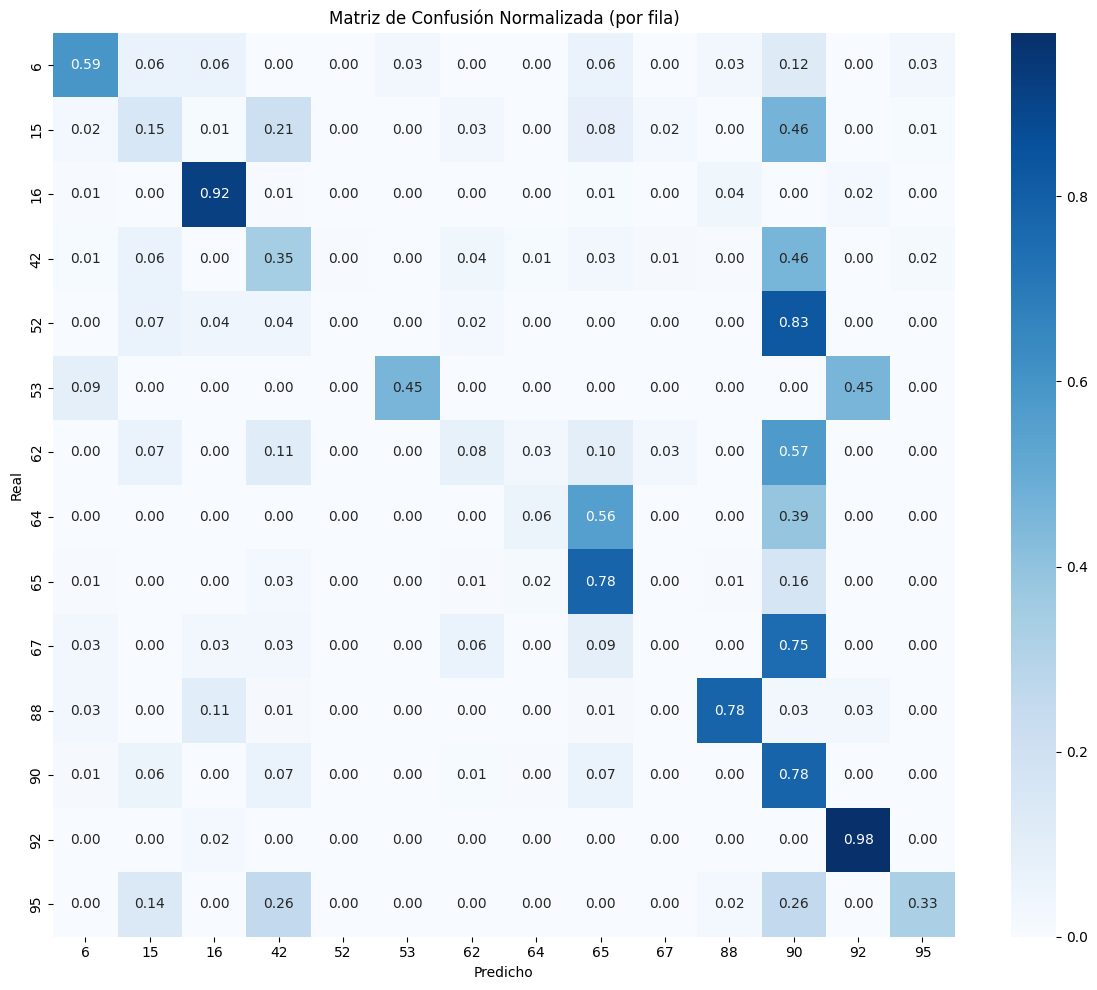

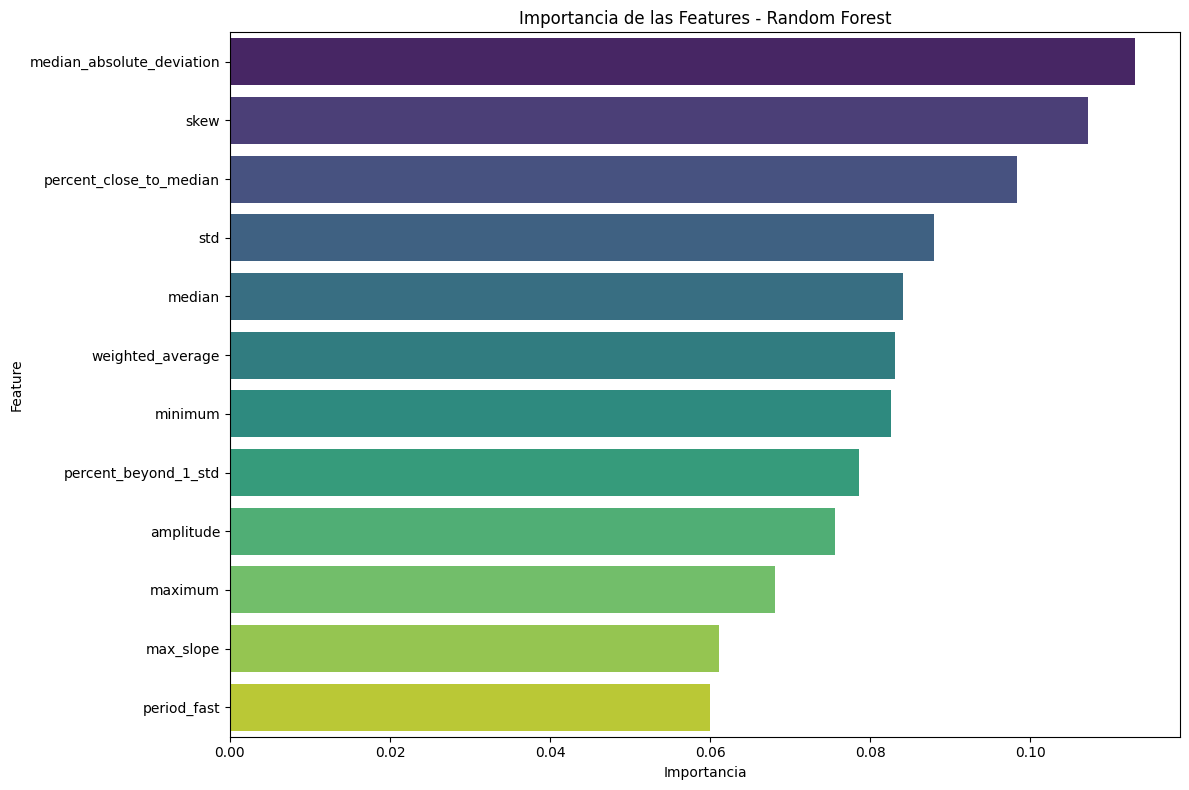

In [42]:
## Este Modelo es un Random Forest simple,
## considera pesos balanceados por clase

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Crear X e y desde las features calculadas
# ==============================
X = features_df.drop(columns=['object_id', 'target'])
y = features_df['target']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print("Ejemplo de y:", y.unique())

# ==============================
# División en train/valid
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# Pesos balanceados por clase
# ==============================
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# ==============================
# Modelo Random Forest
# ==============================
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights
)

# ==============================
# Entrenamiento
# ==============================
rf.fit(X_train, y_train)
print("✅ Random Forest entrenado correctamente.\n")

# ==============================
# Evaluación
# ==============================
y_pred = rf.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print("=== EVALUACIÓN RANDOM FOREST ===")
print(f"Accuracy: {acc:.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_val, y_pred, digits=3))

# ==============================
# Matriz de Confusión Normalizada
# ==============================
print("\n=== MATRIZ DE CONFUSIÓN NORMALIZADA ===")

# Obtener las clases en orden
class_names = sorted(y.unique())

# Calcular matriz de confusión normalizada por filas (true labels)
cm = confusion_matrix(y_val, y_pred, labels=class_names)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Crear heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión Normalizada (por fila)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()
# ==============================
# Importancia de las features
# ==============================
importances = rf.feature_importances_
feature_names = X.columns

# Ordenar por importancia
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Importancia de las Features - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



## Trabajo Futuro para RF (Aplicar Data Aug, ADASYN / SMOTE, etc)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

class_weights_manual = {
    6: 5.0, 15: 3.0, 16: 0.5, 42: 0.8, 52: 8.0, 53: 20.0,
    62: 4.0, 64: 10.0, 65: 0.6, 67: 6.0, 88: 2.0, 90: 0.3,
    92: 3.0, 95: 5.0
}
# ==============================
# 1️⃣ VERIFICACIÓN DE DATOS
# ==============================
print("=== VERIFICACIÓN DE DATOS ===")
print(f"Features_df shape: {features_df.shape}")
print(f"Columnas: {features_df.columns.tolist()}")

# Verificar que tenemos las dimensiones correctas
X = features_df.drop(columns=['object_id', 'target'])
y = features_df['target']

if X.shape[0] != 7848:
    print(f"⚠️  ALERTA: Esperábamos 7848 filas, tenemos {X.shape[0]}")
else:
    print(f"✅ Dimensiones correctas: {X.shape}")

# ==============================
# 2️⃣ DIVISIÓN ESTRATIFICADA
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n=== DIVISIÓN DE DATOS ===")
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

# ==============================
# 3️⃣ PESOS DE CLASE
# ==============================
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))

# ==============================
# 4️⃣ RANDOM FOREST
# ==============================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights_manual
)

print(f"\n=== ENTRENANDO RANDOM FOREST ===")
rf.fit(X_train, y_train)
print("✅ Entrenamiento completado")

# ==============================
# 5️⃣ PREDICCIONES
# ==============================
y_pred = rf.predict(X_val)

print(f"\n=== EVALUACIÓN ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_val, y_pred, digits=3, zero_division=0))

# ==============================
# 6️⃣ MATRIZ DE CONFUSIÓN VISUAL
# ==============================
plt.figure(figsize=(14, 10))

# Crear matriz de confusión
cm = confusion_matrix(y_val, y_pred)

# Obtener nombres de clases
class_names = [f"Clase {cls}" for cls in sorted(np.unique(y))]

# Crear heatmap
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Número de predicciones'})

plt.title('MATRIZ DE CONFUSIÓN - Random Forest\n', fontsize=16, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Añadir métricas adicionales en el gráfico
accuracy = accuracy_score(y_val, y_pred)
plt.figtext(0.5, 0.01, f'Accuracy: {accuracy:.4f} | Total muestras: {len(y_val)}',
            ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

# ==============================
# 7️⃣ MATRIZ NORMALIZADA (OPCIONAL)
# ==============================
plt.figure(figsize=(14, 10))

# Matriz normalizada por filas (recall)
cm_normalized = confusion_matrix(y_val, y_pred, normalize='true')

sns.heatmap(cm_normalized,
            annot=True,
            fmt='.2f',
            cmap='RdYlBu_r',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Proporción'})

plt.title('MATRIZ DE CONFUSIÓN NORMALIZADA (Recall por clase)\n',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ==============================
# 8️⃣ IMPORTANCIA DE FEATURES
# ==============================
print(f"\n=== TOP 10 FEATURES MÁS IMPORTANTES ===")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

# Gráfico de importancia de features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features Más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ==============================
# 1️⃣ ESTRATEGIA AGRESIVA DE DATA AUGMENTATION
# ==============================
print("=== DATA AUGMENTATION EXTREMA ===")

X = features_df.drop(columns=['object_id', 'target'])
y = features_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Distribución original: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# Estrategia de oversampling AGGRESIVA para clases minoritarias
sampling_strategy = {
    6: 1000,    # uLens-Single_GenLens
    15: 1000,   # TDE
    52: 1000,   # SNIax
    53: 1000,   # MIRA (¡FORZAR!)
    62: 1000,   # SNIbc
    64: 1000,   # KN
    67: 1000,   # SNIa-91bg
    88: 1000,   # AGN
    92: 1000,   # RRL
    95: 1000,   # SLSN
    # Clases mayoritarias las dejamos como están
    16: 739, 42: 954, 65: 785, 90: 1850
}

# SMOTE + ADASYN combinado
print("Aplicando SMOTE agresivo...")
smote_aggresive = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=2)
X_train_smote, y_train_smote = smote_aggresive.fit_resample(X_train, y_train)

print("Aplicando ADASYN para variabilidad...")
adasyn = ADASYN(sampling_strategy=sampling_strategy, random_state=42, n_neighbors=2)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print(f"Después SMOTE: {X_train_smote.shape}")
print(f"Después ADASYN: {X_train_adasyn.shape}")
print(f"Distribución SMOTE: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# ==============================
# 2️⃣ ENSEMBLE MEGA-PODEROSO
# ==============================
print("\n" + "="*50)
print("CONSTRUYENDO MEGA-ENSEMBLE")
print("="*50)

# Modelo 1: EasyEnsemble (especialmente bueno para minorías)
print("1. Entrenando EasyEnsemble...")
easy_ensemble = EasyEnsembleClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
easy_ensemble.fit(X_train, y_train)

# Modelo 2: Balanced RF con datos SMOTE
print("2. Entrenando Balanced RF + SMOTE...")
brf_smote = BalancedRandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    min_samples_leaf=1,  # Más sensible a patrones raros
    max_features=0.8,
    sampling_strategy='all',
    replacement=True,
    random_state=42,
    n_jobs=-1
)
brf_smote.fit(X_train_smote, y_train_smote)

# Modelo 3: Balanced RF con datos ADASYN
print("3. Entrenando Balanced RF + ADASYN...")
brf_adasyn = BalancedRandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    min_samples_leaf=1,
    max_features=0.8,
    sampling_strategy='all',
    replacement=True,
    random_state=42,
    n_jobs=-1
)
brf_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Modelo 4: RF con pesos de clase EXTREMOS
print("4. Entrenando RF con pesos extremos...")
class_weights_extreme = {
    6: 15.0, 15: 10.0, 16: 0.3, 42: 0.5, 52: 20.0, 53: 50.0,  # ¡53 con peso 50!
    62: 15.0, 64: 25.0, 65: 0.4, 67: 20.0, 88: 8.0, 90: 0.1,  # 90 casi ignorada
    92: 10.0, 95: 15.0
}

rf_extreme = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,  # Muy flexible
    min_samples_leaf=1,
    max_features=0.6,
    class_weight=class_weights_extreme,
    random_state=42,
    n_jobs=-1
)
rf_extreme.fit(X_train, y_train)

# ==============================
# 3️⃣ ENSEMBLE INTELIGENTE POR CLASE
# ==============================
print("\n=== ENSEMBLE INTELIGENTE ===")

# Obtener predicciones de probabilidad para cada modelo
prob_ee = easy_ensemble.predict_proba(X_val)
prob_brf_smote = brf_smote.predict_proba(X_val)
prob_brf_adasyn = brf_adasyn.predict_proba(X_val)
prob_rf_extreme = rf_extreme.predict_proba(X_val)

# Para cada clase, usar el modelo más confiable
classes = np.unique(y)
y_pred_smart = []

# Calcular confianza de cada modelo por clase (usando training)
def get_class_confidence(model, X_data, y_data):
    from sklearn.metrics import f1_score
    y_pred = model.predict(X_data)
    class_f1 = {}
    for cls in classes:
        mask = y_data == cls
        if np.sum(mask) > 0:
            f1 = f1_score(y_data[mask], y_pred[mask], average='binary', zero_division=0)
            class_f1[cls] = f1
        else:
            class_f1[cls] = 0
    return class_f1

# Ensemble inteligente: para cada muestra, elegir el modelo más confiable para esa clase
for i in range(len(X_val)):
    best_probs = []
    for cls_idx, cls in enumerate(classes):
        # Promedio ponderado de modelos para esta clase
        cls_probs = np.array([
            prob_ee[i, cls_idx],
            prob_brf_smote[i, cls_idx],
            prob_brf_adasyn[i, cls_idx],
            prob_rf_extreme[i, cls_idx]
        ])

        # Dar más peso a modelos especializados en minorías para clases raras
        if cls in [53, 64, 52, 67]:  # Clases más difíciles
            weights = [0.1, 0.3, 0.3, 0.3]  # Más peso a modelos balanceados
        else:
            weights = [0.25, 0.25, 0.25, 0.25]  # Peso equilibrado

        weighted_prob = np.average(cls_probs, weights=weights)
        best_probs.append(weighted_prob)

    predicted_class = classes[np.argmax(best_probs)]
    y_pred_smart.append(predicted_class)

y_pred_smart = np.array(y_pred_smart)

# ==============================
# 4️⃣ EVALUACIÓN EXTREMA
# ==============================
print("\n" + "="*50)
print("EVALUACIÓN DEL MEGA-ENSEMBLE")
print("="*50)

acc_smart = accuracy_score(y_val, y_pred_smart)
macro_f1_smart = f1_score(y_val, y_pred_smart, average='macro', zero_division=0)

print(f"Accuracy: {acc_smart:.4f}")
print(f"Macro F1: {macro_f1_smart:.4f}")

print("\n=== REPORTE POR CLASE ===")
print(classification_report(y_val, y_pred_smart, digits=3, zero_division=0))

# ==============================
# 5️⃣ MATRIZ DE CONFUSIÓN NORMALIZADA (RECALL)
# ==============================
print("\n=== MATRIZ DE CONFUSIÓN NORMALIZADA (RECALL por clase) ===")

plt.figure(figsize=(16, 12))
# Normalizar por filas = RECALL (qué % de cada clase real fue correctamente predecido)
cm_normalized = confusion_matrix(y_val, y_pred_smart, normalize='true')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlBu_r',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proporción de predicciones correctas'})

plt.title('MATRIZ DE CONFUSIÓN NORMALIZADA - RECALL POR CLASE\n(Qué % de cada clase real se predijo correctamente)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicción', fontsize=12, labelpad=10)
plt.ylabel('Valor Real', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.figtext(0.5, 0.01,
           f'Matriz normalizada por filas (Recall) | Diagonal = % correcto por clase',
           ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# ==============================
# 6️⃣ CELEBRACIÓN - ANÁLISIS CLASE 53
# ==============================




print(f"\nDistribución final después de data augmentation:")
for cls, count in zip(*np.unique(y_train_smote, return_counts=True)):
    original = dict(zip(*np.unique(y_train, return_counts=True)))[cls]
    print(f"Clase {cls}: {original} → {count} ejemplos ({count/original:.1f}x)")

# GMM

F1 macro: 0.36103637046437864

Reporte de clasificación:
               precision    recall  f1-score   support

           6       0.46      0.20      0.28        30
          15       0.17      0.33      0.22        99
          16       0.91      0.75      0.82       185
          42       0.40      0.03      0.05       239
          52       0.02      0.08      0.03        36
          53       0.50      0.83      0.62         6
          62       0.14      0.10      0.12        97
          64       0.08      0.75      0.14        20
          65       0.82      0.32      0.46       196
          67       0.08      0.26      0.12        42
          88       0.57      0.85      0.68        74
          90       0.47      0.33      0.39       463
          92       0.85      0.85      0.85        48
          95       0.23      0.31      0.27        35

    accuracy                           0.36      1570
   macro avg       0.41      0.43      0.36      1570
weighted avg       0.5

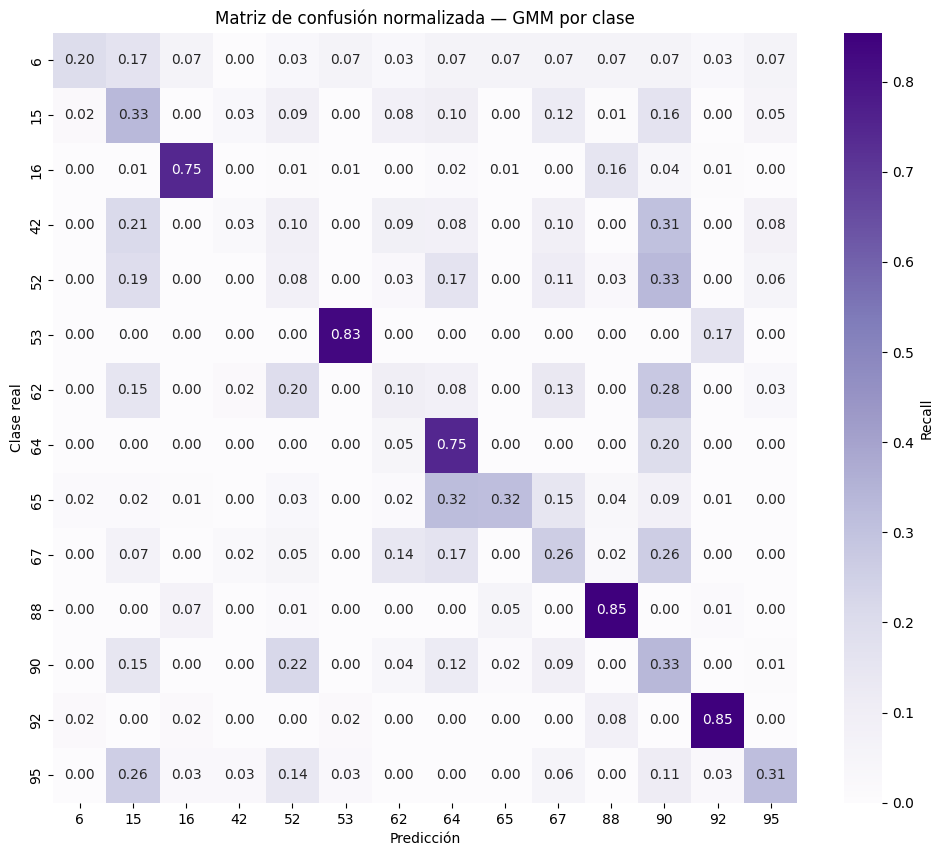

In [40]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# Preparar datos
# ===============================
X = features_df.drop(columns=['object_id', 'target'])
y = features_df['target']

# Estandarizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Entrenar un GMM por clase
# ===============================
n_componentes = 2
gmm_models = {}

for clase in np.unique(y_train):
    gmm = GaussianMixture(n_components=n_componentes, covariance_type='full', random_state=42)
    gmm.fit(X_train[y_train == clase])
    gmm_models[clase] = gmm

# ===============================
# Clasificar validación
# ===============================
log_likelihoods = np.zeros((len(X_val), len(gmm_models)))

for i, clase in enumerate(gmm_models.keys()):
    log_likelihoods[:, i] = gmm_models[clase].score_samples(X_val)

y_pred = np.array([list(gmm_models.keys())[idx] for idx in np.argmax(log_likelihoods, axis=1)])

# ===============================
# Métricas de evaluación
# ===============================
print("F1 macro:", f1_score(y_val, y_pred, average='macro'))
print("\nReporte de clasificación:\n", classification_report(y_val, y_pred))

# ===============================
# Matriz de confusión normalizada
# ===============================
matriz = confusion_matrix(y_val, y_pred, normalize='true')  # normalizada por filas
class_names = sorted(y.unique())

plt.figure(figsize=(12,10))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Recall'})
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión normalizada — GMM por clase")
plt.show()


# Funcion Entrenamiento CNN

In [36]:
# ==============================
# 3. FUNCIONES DE ENTRENAMIENTO - CORREGIDAS
# ==============================

def train_step(x_batch, y_batch, model, optimizer, criterion, use_gpu):
    # Predicción
    y_predicted = model(x_batch)

    # Cálculo de loss
    loss = criterion(y_predicted, y_batch)

    # Actualización de parámetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return y_predicted, loss

def evaluate(val_loader, model, criterion, use_gpu):
    cumulative_loss = 0
    cumulative_predictions = 0
    data_count = 0

    model.eval()
    with torch.no_grad():
        for x_val, y_val in val_loader:
            if use_gpu:
                x_val = x_val.cuda()
                y_val = y_val.cuda()

            y_predicted = model(x_val)
            loss = criterion(y_predicted, y_val)

            class_prediction = torch.argmax(y_predicted, axis=1)
            cumulative_predictions += (y_val == class_prediction).sum().item()
            cumulative_loss += loss.item()
            data_count += y_val.shape[0]

    val_acc = cumulative_predictions / data_count
    val_loss = cumulative_loss / len(val_loader)

    return val_acc, val_loss

def train_model(model, train_dataset, val_dataset, epochs, criterion,
                batch_size=32, lr=0.001, n_evaluations_per_epoch=4,
                use_gpu=False):

    if use_gpu:
        model.cuda()

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    # Optimizador
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Listas para curvas
    curves = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
    }

    t0 = time.perf_counter()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        # Entrenamiento
        model.train()
        cumulative_train_loss = 0
        cumulative_train_corrects = 0
        total_samples = 0  # ✅ NUEVO: contador exacto de muestras

        for i, (x_batch, y_batch) in enumerate(train_loader):
            if use_gpu:
                x_batch = x_batch.cuda()
                y_batch = y_batch.cuda()

            y_predicted, loss = train_step(x_batch, y_batch, model, optimizer, criterion, use_gpu)

            # ✅ CORREGIDO: Ponderar loss por batch size
            cumulative_train_loss += loss.item() * x_batch.size(0)

            # Calcular accuracy
            class_prediction = torch.argmax(y_predicted, axis=1)
            cumulative_train_corrects += (y_batch == class_prediction).sum().item()
            total_samples += x_batch.size(0)  # ✅ Contar muestras reales

            # Evaluación intermedia
            if (i % (len(train_loader) // n_evaluations_per_epoch) == 0) and (i > 0):
                # ✅ CORREGIDO: Usar muestras reales, no batches
                train_loss_interim = cumulative_train_loss / total_samples
                train_acc_interim = cumulative_train_corrects / total_samples
                print(f"  Batch {i}/{len(train_loader)} - Train loss: {train_loss_interim:.4f}, Train acc: {train_acc_interim:.4f}")

        # ✅ CORREGIDO: Cálculo final EXACTO
        train_loss = cumulative_train_loss / total_samples
        train_acc = cumulative_train_corrects / total_samples

        # Evaluación final de la época
        val_acc, val_loss = evaluate(val_loader, model, criterion, use_gpu)

        print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")
        print(f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

        # Guardar curvas
        curves["train_acc"].append(train_acc)
        curves["val_acc"].append(val_acc)
        curves["train_loss"].append(train_loss)
        curves["val_loss"].append(val_loss)

    print(f"\nTiempo total de entrenamiento: {time.perf_counter() - t0:.2f} [s]")
    model.cpu()

    return curves

# Nuevo CNN

In [25]:
#==============================
# 3. FUNCIONES DE ENTRENAMIENTO
# ==============================

def train_step(x_batch, y_batch, model, optimizer, criterion, use_gpu):
    # Predicción
    y_predicted = model(x_batch)

    # Cálculo de loss
    loss = criterion(y_predicted, y_batch)

    # Actualización de parámetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return y_predicted, loss

def evaluate(val_loader, model, criterion, use_gpu):
    cumulative_loss = 0
    cumulative_predictions = 0
    data_count = 0

    model.eval()
    with torch.no_grad():
        for x_val, y_val in val_loader:
            if use_gpu:
                x_val = x_val.cuda()
                y_val = y_val.cuda()

            y_predicted = model(x_val)
            loss = criterion(y_predicted, y_val)

            class_prediction = torch.argmax(y_predicted, axis=1)
            cumulative_predictions += (y_val == class_prediction).sum().item()
            cumulative_loss += loss.item()
            data_count += y_val.shape[0]

    val_acc = cumulative_predictions / data_count
    val_loss = cumulative_loss / len(val_loader)

    return val_acc, val_loss

def train_model(model, train_dataset, val_dataset, epochs, criterion,
                batch_size=32, lr=0.001, n_evaluations_per_epoch=4,
                use_gpu=False):

    if use_gpu:
        model.cuda()

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=len(val_dataset),
        shuffle=False,
        collate_fn=collate_fn
    )


    # Optimizador
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Listas para curvas
    curves = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
    }

    t0 = time.perf_counter()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        # Entrenamiento
        model.train()
        cumulative_train_loss = 0
        cumulative_train_corrects = 0
        train_count = 0

        for i, (x_batch, y_batch) in enumerate(train_loader):
            if use_gpu:
                x_batch = x_batch.cuda()
                y_batch = y_batch.cuda()

            y_predicted, loss = train_step(x_batch, y_batch, model, optimizer, criterion, use_gpu)

            cumulative_train_loss += loss.item()
            train_count += 1

            # Calcular accuracy
            class_prediction = torch.argmax(y_predicted, axis=1)
            cumulative_train_corrects += (y_batch == class_prediction).sum().item()

            # Evaluación intermedia
            if (i % (len(train_loader) // n_evaluations_per_epoch) == 0) and (i > 0):
                train_loss = cumulative_train_loss / train_count
                train_acc = cumulative_train_corrects / (batch_size * train_count)
                print(f"  Batch {i}/{len(train_loader)} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")

        # Evaluación final de la época
        val_acc, val_loss = evaluate(val_loader, model, criterion, use_gpu)

        train_loss = cumulative_train_loss / len(train_loader)
        train_acc = cumulative_train_corrects / len(train_dataset)

        print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")
        print(f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

        # Guardar curvas
        curves["train_acc"].append(train_acc)
        curves["val_acc"].append(val_acc)
        curves["train_loss"].append(train_loss)
        curves["val_loss"].append(val_loss)

    print(f"\nTiempo total de entrenamiento: {time.perf_counter() - t0:.2f} [s]")
    model.cpu()

    return curves

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_normalized(y_true, y_pred, class_names, title="Matriz de Confusión Normalizada"):
    """
    Plot matriz de confusión normalizada por filas (Recall)

    Args:
        y_true: etiquetas reales
        y_pred: etiquetas predichas
        class_names: nombres de las clases
        title: título del gráfico
    """
    # Calcular matriz normalizada
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    # Crear figura
    plt.figure(figsize=(12, 10))

    # Heatmap
    sns.heatmap(cm,
                annot=True,
                fmt='.2f',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Recall'})

    plt.title(f'{title}\n(Normalizada por filas - Recall por clase)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicción', fontsize=12, labelpad=10)
    plt.ylabel('Valor Real', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    # Añadir accuracy en el pie
    accuracy = np.mean(y_true == y_pred)
    plt.figtext(0.5, 0.01,
                f'Accuracy: {accuracy:.4f} | Total muestras: {len(y_true)}',
                ha='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

    return cm

In [31]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np

# ==============================
# DATASET PARA CNN (SERIES TEMPORALES)
# ==============================
class LightCurveCNNDataset(Dataset):
    def __init__(self, metadata_df, objects_dict, max_length=150):
        """
        Dataset para CNN usando series temporales RAW

        Args:
            metadata_df: DataFrame con object_id y target
            objects_dict: Diccionario 'objects' que ya tenemos
            max_length: Longitud máxima de secuencia
        """
        self.metadata = metadata_df
        self.objects = objects_dict
        self.max_length = max_length

        # Crear mapeo de target a índice (0-13)
        self.unique_targets = sorted(metadata_df['target'].unique())
        self.target_to_idx = {target: idx for idx, target in enumerate(self.unique_targets)}

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # Obtener object_id y target
        obj_id = self.metadata.iloc[idx]['object_id']
        target = self.metadata.iloc[idx]['target']

        # Obtener datos de la serie temporal del diccionario 'objects'
        obj_data = self.objects[obj_id]
        mjd = obj_data['mjd']
        flux = obj_data['flux']
        flux_err = obj_data['flux_err']
        passband = obj_data['passband']

        # Limitar longitud máxima
        n_obs = min(len(mjd), self.max_length)

        # Crear tensor de características: [time, passband, flux, flux_err]
        features = np.zeros((n_obs, 4), dtype=np.float32)

        # Normalizaciones para CNN:
        features[:, 0] = (mjd[:n_obs] - np.min(mjd[:n_obs])) / (np.ptp(mjd[:n_obs]) + 1e-6)  # tiempo 0-1
        features[:, 1] = passband[:n_obs] / 5.0  # passband 0-1
        features[:, 2] = flux[:n_obs] / (np.std(flux[:n_obs]) + 1e-6)  # flux normalizado
        features[:, 3] = flux_err[:n_obs] / (np.std(flux_err[:n_obs]) + 1e-6)  # flux_err normalizado

        # Convertir a tensores
        X = torch.FloatTensor(features)
        y = torch.tensor(self.target_to_idx[target], dtype=torch.long)

        return X, y

# ==============================
# COLLATE FUNCTION PARA PADDING
# ==============================
def collate_fn(batch):
    """Collate function para padding de secuencias temporales"""
    sequences, targets = zip(*batch)

    # Padding de secuencias
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    targets = torch.stack(targets)

    return sequences_padded, targets

In [28]:
import torch.nn as nn
import torch.nn.functional as F

class LightCurveCNN(nn.Module):
    def __init__(self, input_dim=4, num_classes=14):
        super(LightCurveCNN, self).__init__()

        # Capas convolucionales 1D
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)

        self.conv4 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(512)

        # Pooling adaptativo
        self.pool = nn.AdaptiveAvgPool1d(8)

        # Capas fully connected
        self.fc1 = nn.Linear(512 * 8, 512)
        self.dropout1 = nn.Dropout(0.4)

        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        # x shape: [batch_size, seq_len, features]
        # Transponer para Conv1d: [batch_size, features, seq_len]
        x = x.transpose(1, 2)

        # Bloque 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=2)

        # Bloque 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=2)

        # Bloque 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool1d(x, kernel_size=2)

        # Bloque 4
        x = F.relu(self.bn4(self.conv4(x)))

        # Pooling global
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)

        x = F.relu(self.fc2(x))
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [29]:
# ==============================
# PREPARAR DATOS PARA CNN
# ==============================
print("=== PREPARANDO DATOS CNN ===")

# 1. Filtrar metadata para objetos que tenemos
available_ids = list(objects.keys())
metadata_filtered = train_metadata[train_metadata['object_id'].isin(available_ids)].copy()

print(f"Objetos disponibles: {len(available_ids)}")
print(f"Metadata filtrada: {len(metadata_filtered)}")

# 2. Split estratificado
from sklearn.model_selection import train_test_split

train_meta, val_meta = train_test_split(
    metadata_filtered,
    test_size=0.2,
    random_state=42,
    stratify=metadata_filtered['target']
)

print(f"Training: {len(train_meta)}")
print(f"Validation: {len(val_meta)}")

# 3. Crear datasets
train_dataset_cnn = LightCurveCNNDataset(train_meta, objects, max_length=150)
val_dataset_cnn = LightCurveCNNDataset(val_meta, objects, max_length=150)

print(f"Dataset train: {len(train_dataset_cnn)}")
print(f"Dataset val: {len(val_dataset_cnn)}")

# 4. Verificar un ejemplo
X_sample, y_sample = train_dataset_cnn[0]
print(f"Ejemplo - X shape: {X_sample.shape}, y: {y_sample.item()}")

=== PREPARANDO DATOS CNN ===
Objetos disponibles: 7848
Metadata filtrada: 7848
Training: 6278
Validation: 1570
Dataset train: 6278
Dataset val: 1570
Ejemplo - X shape: torch.Size([144, 4]), y: 2


🚀 INICIANDO ENTRENAMIENTO CNN
Modelo creado: 2,769,230 parámetros

--- INICIANDO ENTRENAMIENTO ---

Epoch 1/50
  Batch 98/197 - Train loss: 2.4120, Train acc: 0.1840
  Batch 196/197 - Train loss: 2.2552, Train acc: 0.2018
Train loss: 2.2552, Train acc: 0.2026
Val loss: 2.0062, Val acc: 0.2726

Epoch 2/50
  Batch 98/197 - Train loss: 1.9522, Train acc: 0.2664
  Batch 196/197 - Train loss: 1.8849, Train acc: 0.2709
Train loss: 1.8849, Train acc: 0.2721
Val loss: 1.7791, Val acc: 0.2885

Epoch 3/50
  Batch 98/197 - Train loss: 1.7567, Train acc: 0.3217
  Batch 196/197 - Train loss: 1.7464, Train acc: 0.3108
Train loss: 1.7464, Train acc: 0.3120
Val loss: 1.6058, Val acc: 0.3815

Epoch 4/50
  Batch 98/197 - Train loss: 1.6123, Train acc: 0.3393
  Batch 196/197 - Train loss: 1.6227, Train acc: 0.3418
Train loss: 1.6227, Train acc: 0.3433
Val loss: 1.7046, Val acc: 0.3783

Epoch 5/50
  Batch 98/197 - Train loss: 1.5701, Train acc: 0.3258
  Batch 196/197 - Train loss: 1.5569, Train acc: 0.335

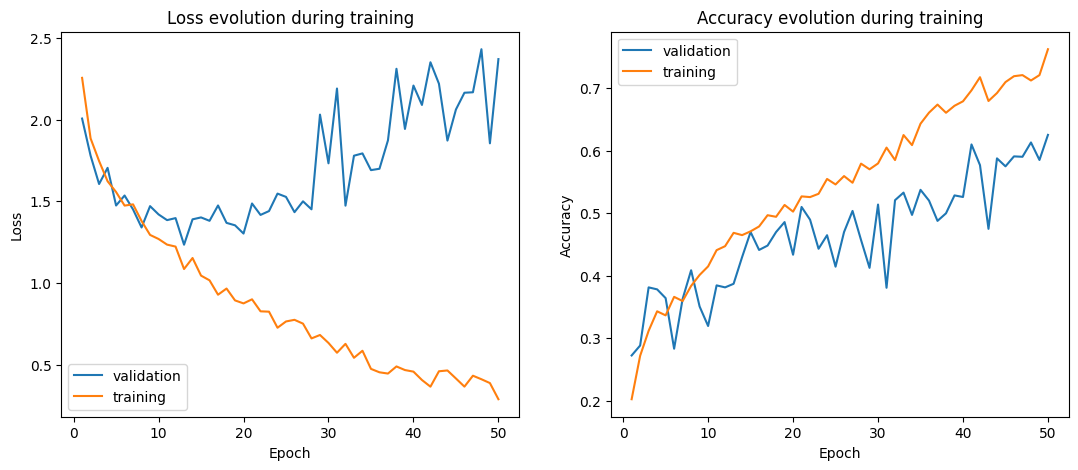


🎯 GENERANDO MATRIZ DE CONFUSIÓN

--- MATRIZ DE CONFUSIÓN NORMALIZADA ---


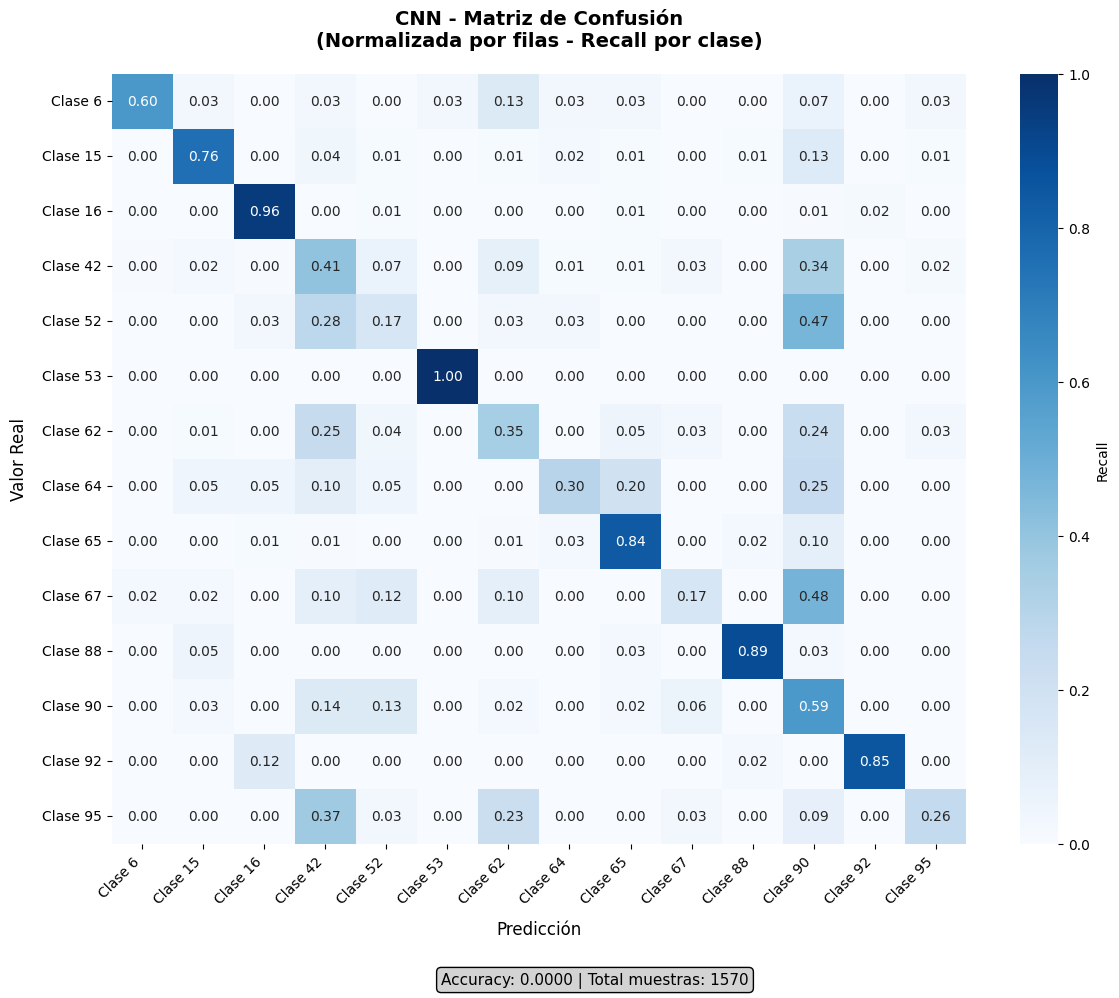


--- REPORTE DE CLASIFICACIÓN CNN ---
              precision    recall  f1-score   support

           6      0.857     0.600     0.706        30
          15      0.750     0.758     0.754        99
          16      0.937     0.957     0.947       185
          42      0.445     0.410     0.427       239
          52      0.061     0.167     0.090        36
          53      0.857     1.000     0.923         6
          62      0.400     0.351     0.374        97
          64      0.333     0.300     0.316        20
          65      0.859     0.837     0.848       196
          67      0.159     0.167     0.163        42
          88      0.917     0.892     0.904        74
          90      0.595     0.594     0.595       463
          92      0.932     0.854     0.891        48
          95      0.474     0.257     0.333        35

    accuracy                          0.625      1570
   macro avg      0.613     0.582     0.591      1570
weighted avg      0.645     0.625     0.63

In [35]:
# ==============================
# ENTRENAMIENTO CNN + MATRIZ DE CONFUSIÓN
# ==============================
print("🚀 INICIANDO ENTRENAMIENTO CNN")

# 1. Crear modelo
model_cnn = LightCurveCNN(num_classes=len(train_dataset_cnn.unique_targets))
print(f"Modelo creado: {sum(p.numel() for p in model_cnn.parameters()):,} parámetros")

# 2. Loss function con pesos para desbalance
all_targets = [train_dataset_cnn[i][1].item() for i in range(len(train_dataset_cnn))]
class_counts = np.bincount(all_targets)
class_weights = 1.0 / class_counts
class_weights = torch.FloatTensor(class_weights / class_weights.sum())

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# 3. ENTRENAR con TU función
print("\n--- INICIANDO ENTRENAMIENTO ---")
curves = train_model(
    model=model_cnn,
    train_dataset=train_dataset_cnn,
    val_dataset=val_dataset_cnn,
    epochs=50,
    criterion=criterion,
    batch_size=32,
    lr=0.001,
    n_evaluations_per_epoch=2,
    use_gpu=False  # Cambiar a True si tienes GPU
)

# 4. Visualizar curvas de entrenamiento
print("\n--- CURVAS DE ENTRENAMIENTO ---")
show_curves(curves)

# ==============================
# MATRIZ DE CONFUSIÓN
# ==============================
print("\n🎯 GENERANDO MATRIZ DE CONFUSIÓN")

# Obtener todas las predicciones del validation set
model_cnn.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for X_val, y_val in DataLoader(val_dataset_cnn, batch_size=32, collate_fn=collate_fn):
        outputs = model_cnn(X_val)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.numpy())
        all_targets.extend(y_val.numpy())

# Convertir a numpy
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Mapear índices a nombres de clase originales
idx_to_class = {idx: cls for cls, idx in train_dataset_cnn.target_to_idx.items()}
predicted_classes = [idx_to_class[idx] for idx in all_predictions]
true_classes = [idx_to_class[idx] for idx in all_targets]

# Nombres de clases para la matriz
class_names = [f"Clase {cls}" for cls in train_dataset_cnn.unique_targets]

# Plot matriz de confusión normalizada
print("\n--- MATRIZ DE CONFUSIÓN NORMALIZADA ---")
cm = plot_confusion_matrix_normalized(
    y_true=true_classes,
    y_pred=predicted_classes,
    class_names=class_names,
    title="CNN - Matriz de Confusión"
)

# Reporte de clasificación final
from sklearn.metrics import classification_report

print("\n--- REPORTE DE CLASIFICACIÓN CNN ---")
print(classification_report(true_classes, predicted_classes, digits=3, zero_division=0))

# Accuracy final
accuracy = np.mean(np.array(true_classes) == np.array(predicted_classes))
print(f"🎯 ACCURACY FINAL CNN: {accuracy:.4f}")

print("\n✅ ENTRENAMIENTO CNN COMPLETADO!")